# Fit Results Diagnostics

This notebook visualizes outputs from `runfit.py`.

It produces:
1. Kinematic distributions used in the fit
2. Comparison between original and reconstructed cross sections
3. Comparison of parameter values before/after fit (and fixed vs fitted roles)
4. Goodness-of-fit diagnostics commonly inspected in data fitting workflows

## Set fit results directory

In [1]:
import pathlib
FITRESULTS_DIR = pathlib.Path('results/fitresults')

## Set up

### Import libraries and define plotting parameters

In [2]:
import sys

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add parent directory to path so sidis can be imported as a package
parent_dir = pathlib.Path().resolve().parent.parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

from sidis.model import TrainableModel
from sidis.utilities.colors import tcolors

# Plotting parameters
import matplotlib as mpl

# Ensure the style is available
available_styles = mpl.style.available
if "seaborn-talk" in available_styles:
    mpl.style.use("seaborn-talk")
elif "seaborn-v0_8-talk" in available_styles:
    mpl.style.use("seaborn-v0_8-talk")
else:
    mpl.style.use("seaborn-v0_8-whitegrid")

mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"\usepackage{bm}"
mpl.rcParams["font.weight"] = "bold"

# Disable grid by default
mpl.rcParams["axes.grid"] = False

# Axes
mpl.rcParams["axes.linewidth"] = 1.3
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.labelsize"] = 12


# Ticks
mpl.rcParams["xtick.direction"] = "in"
mpl.rcParams["xtick.top"] = True
mpl.rcParams["xtick.major.size"] = 10
mpl.rcParams["xtick.major.width"] = 1.3
mpl.rcParams["xtick.minor.size"] = 5
mpl.rcParams["xtick.minor.width"] = 1.3
mpl.rcParams["xtick.minor.visible"] = True
mpl.rcParams["xtick.labelsize"] = 10

mpl.rcParams["ytick.direction"] = "in"
mpl.rcParams["ytick.right"] = True
mpl.rcParams["ytick.major.size"] = 10
mpl.rcParams["ytick.major.width"] = 1.3
mpl.rcParams["ytick.minor.size"] = 5
mpl.rcParams["ytick.minor.width"] = 1.3
mpl.rcParams["ytick.minor.visible"] = True
mpl.rcParams["ytick.labelsize"] = 10




### Set folders

In [3]:
# Default location produced by runfit.py
FIT_FILE = FITRESULTS_DIR / 'fitresults.yaml'
FIT_PARAMS_FILE = FITRESULTS_DIR / 'parameters.yaml'
FIT_LOSS_FILE = FITRESULTS_DIR / 'loss.yaml'

print(f'Fit results file   : {FIT_FILE.resolve()}')
print(f'Fit parameters file : {FIT_PARAMS_FILE.resolve()}')
print(f'Fit loss file      : {FIT_LOSS_FILE.resolve()}')

if not FIT_FILE.exists() or not FIT_PARAMS_FILE.exists() or not FIT_LOSS_FILE.exists():
    raise FileNotFoundError(
        'Missing fitresults files. Run runfit.py first, or edit FITRESULTS_DIR in this notebook.'
    )
    
    
# Create plot directory 
PLOT_DIR = pathlib.Path(f'{FITRESULTS_DIR}/plots')
PLOT_DIR.mkdir(exist_ok=True)
print(f"\n{tcolors.BOLDGREEN}Plot directory:{tcolors.ENDC} {PLOT_DIR.resolve()}")


Fit results file   : /Users/cbissolotti/anl/projects/tmd/sidis/tests/results/fitresults/fitresults.yaml
Fit parameters file : /Users/cbissolotti/anl/projects/tmd/sidis/tests/results/fitresults/parameters.yaml
Fit loss file      : /Users/cbissolotti/anl/projects/tmd/sidis/tests/results/fitresults/loss.yaml

Plot directory: /Users/cbissolotti/anl/projects/tmd/sidis/tests/results/fitresults/plots


### Load fit results
 Load fit results in panda dataframes from all files in the fitresults directory.
 

In [4]:
with open(FIT_FILE, 'r') as f:
    fit_data = yaml.safe_load(f)

with open(FIT_PARAMS_FILE, 'r') as f:
    fit_params = yaml.safe_load(f)
    
with open(FIT_LOSS_FILE, 'r') as f:
    fit_loss = yaml.safe_load(f)

cross_section_df = pd.DataFrame(fit_data['data'])
param_df = pd.DataFrame(fit_params['parameters'])
loss_df = pd.DataFrame(fit_loss['loss'])

print(f'{tcolors.BOLDGREEN}Loaded points:{tcolors.ENDC}', len(cross_section_df), f'{tcolors.ENDC}')
print(f'{tcolors.GREEN}Columns:{tcolors.ENDC}', list(cross_section_df.columns))
print(f'{tcolors.BOLDGREEN}Number of parameter entries:{tcolors.ENDC}', len(param_df), f'{tcolors.ENDC}')

# Check
# Print the first 5 rows of the parameter dataframe
param_df.head(5)

# Print message that says that all dataframes have been loaded correctly
print(f'{tcolors.BOLDGREEN}All dataframes have been loaded correctly.{tcolors.ENDC}')


Loaded points: 1000 
Columns: ['x', 'PhT', 'Q', 'z', 'cross_section_original', 'cross_section_reconstructed']
Number of parameter entries: 33 
All dataframes have been loaded correctly.


## I. Kinematics used in the fit

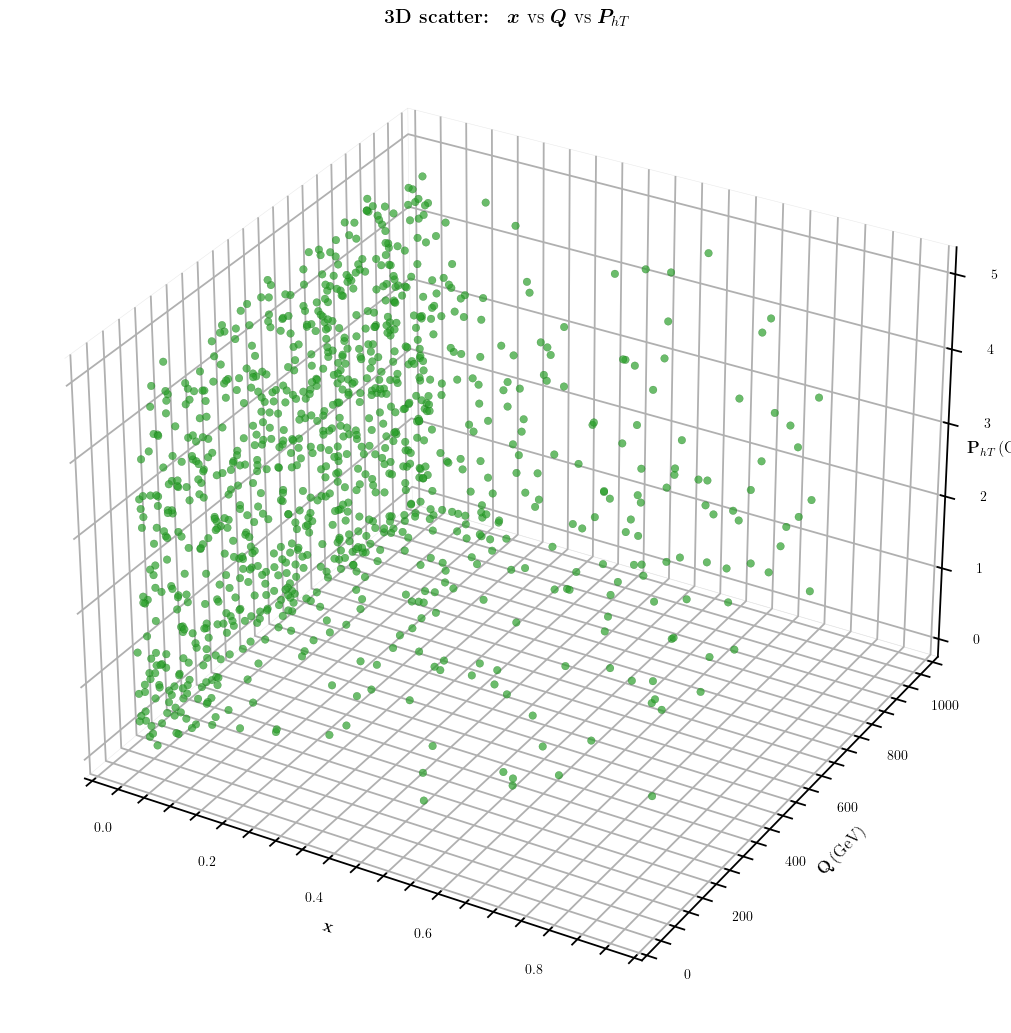

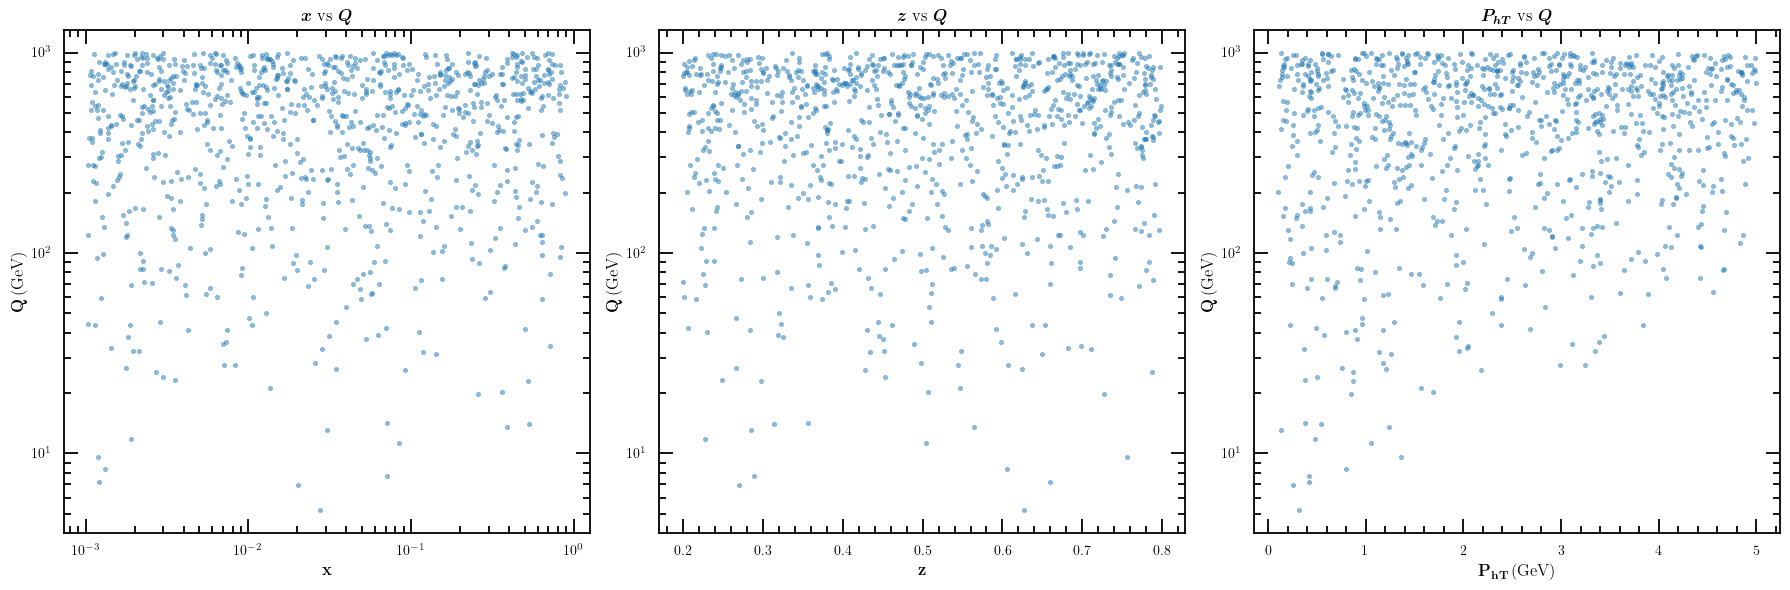

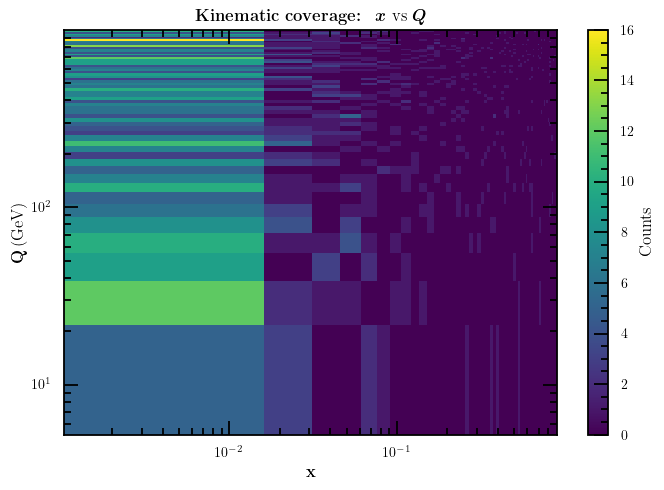

In [5]:
kin_cols = [c for c in ['x', 'PhT', 'Q', 'z'] if c in cross_section_df.columns]
if len(kin_cols) < 4:
    print('Warning: expected x, PhT, Q, z columns; found:', kin_cols)
    
# Conveniente change of variables
df = cross_section_df

# -------------------------------------------------------------------------------------------------
# Plot the 3D scatter plot of x vs Q vs PhT
# -------------------------------------------------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 18), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    cross_section_df['x'], cross_section_df['Q'], cross_section_df['PhT'],
    alpha=0.7, s=30, c='tab:green', edgecolors='darkgreen', linewidth=0.2
)

ax.set_xlabel(r'$\mathbf{x}$', fontsize=12, labelpad=10)
ax.set_ylabel(r'$\mathbf{Q}\,(\mathrm{GeV})$', fontsize=12, labelpad=10)
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r'$\mathbf{P}_{hT}\,(\mathrm{GeV})$', fontsize=12, labelpad=5)
# ax.set_title(r'$\mathbf{3D scatter:} x\ \mathrm{vs}\ Q\ \mathrm{vs}\ P_{hT}$', fontsize=14)
ax.set_title(r'\textbf{3D scatter: } $\bm{x}$ vs $\bm{Q}$ vs $\bm{P}_{hT}$', fontsize=14)

ax.grid(True, alpha=0.1)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('lightgray')
ax.yaxis.pane.set_edgecolor('lightgray')
ax.zaxis.pane.set_edgecolor('lightgray')


plt.savefig(f"{PLOT_DIR}/scatter3d.pdf", bbox_inches="tight", pad_inches=0.8)
plt.show()

# -------------------------------------------------------------------------------------------------
# Plot the 2D scatter plots of x vs Q, z vs Q, and PhT vs Q
# -------------------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# x vs Q (log scale on Q)
ax = axes[0]
ax.scatter(df['x'], df['Q'], alpha=0.5, s=10, color='tab:blue')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\mathbf{x}$')
ax.set_ylabel(r'$\mathbf{Q} \, \mathbf{\rm{(GeV)}}$')
ax.set_title(r'$\bm{x}$ vs $\bm{Q}$')

# z vs Q (linear)
ax = axes[1]
ax.scatter(df['z'], df['Q'], alpha=0.5, s=10, color='tab:blue')
ax.set_xlabel(r'$\mathbf{z}$')
ax.set_yscale('log')
ax.set_ylabel(r'$\mathbf{Q} \, \mathbf{\rm{(GeV)}}$')
ax.set_title(r'$\bm{z}$ vs $\bm{Q}$')

# PhT vs Q
ax = axes[2]
ax.scatter(df['PhT'], df['Q'], alpha=0.5, s=10, color='tab:blue')
ax.set_xlabel(r'$\mathbf{P_{hT}} \, \mathbf{\rm{(GeV)}}$')
ax.set_yscale('log')
ax.set_ylabel(r'$\mathbf{Q} \, \mathbf{\rm{(GeV)}}$')
ax.set_title(r'$\bm{P_{hT}}$ vs $\bm{Q}$')


plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/kinematic_coverage.pdf", bbox_inches="tight", pad_inches=0.8)
plt.show()

# -------------------------------------------------------------------------------------------------
# Kinematic coverage 2D map (x vs Q)
# -------------------------------------------------------------------------------------------------
if {'x', 'Q'}.issubset(df.columns):
    plt.figure(figsize=(7, 5))
    plt.hist2d(df['x'], df['Q'], bins=60, cmap='viridis')
    plt.yscale('log')
    plt.xscale('log')
    plt.colorbar(label='Counts')
    plt.xlabel(r'$\mathbf{x}$')
    plt.ylabel(r'$\mathbf{Q} \, \mathbf{\rm{(GeV)}}$')
    plt.title(r'\textbf{Kinematic coverage: } $\bm{x}$ vs $\bm{Q}$')
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/kinematic_coverage_2D_x_vs_Q.pdf", bbox_inches="tight", pad_inches=0.8)
    plt.show()

## II. Cross Section Comparison

Original (`cross_section_original`) vs reconstructed (`cross_section_reconstructed`).

In [6]:
# Get cross sections to plot from fitresults.yaml
cs_true = cross_section_df['cross_section_original'].to_numpy()
cs_pred = cross_section_df['cross_section_reconstructed'].to_numpy()

# Compute log-space values, with a small epsilon to avoid log(0)
eps = 1e-40
log_true = np.log(np.clip(np.abs(cs_true), eps, None))
log_pred = np.log(np.clip(np.abs(cs_pred), eps, None))

# Compute difference and ratio between prediction and original cross section.
# Compute cs_pred/cs_true where cs_true != 0; otherwise NaN (avoids division by zero).
# Compute also the log-ratio between prediction and original cross section.
residual = cs_pred - cs_true
ratio = np.where(np.abs(cs_true) > 0, cs_pred / cs_true, np.nan)
log_ratio = log_pred - log_true


### Interpretation notes

__I. PARITY PLOT__

A parity plot compares predicted vs true values on a scatter plot where the x-axis is the true (or reference) value and the y-axis is the predicted value.

**Ideal line:** The diagonal `y = x` (here `[mn, mx], [mn, mx]`) is the “perfect fit” line. Points on this line mean predicted = true.

**How to read it:**
- **On the diagonal** → prediction matches truth
- **Above the diagonal** → overprediction
- **Below the diagonal** → underprediction
- **Spread around the line** → size of the error

**In this plot:** The plot is in **log-space** (`log_true` vs `log_pred`), so it shows how well the model matches the original cross sections on a log scale. The red dashed line is the ideal `log_pred = log_true` line.


__II. RESIDUAL HISTOGRAM__

Histogram of residuals in linear space:

Residual = `reconstructed σ − original σ` = prediction − truth

So each bin counts how many kinematic points have a given residual. 
- Residual = reconstructed cross section − original cross section. A narrow, centered distribution indicates good fit.
- Each bin counts how many kinematic points have that residual. Centered at 0 means no systematic bias.
- Residuals centered at 0 with small spread → good agreement between model and target.

**How to read it**

- **Centered at 0** → predictions are unbiased (no systematic over/underprediction)
- **Narrow** → small errors
- **Wide** → large scatter
- **Skewed** → systematic bias (e.g. more over- or underpredictions)
- **Symmetric** → errors are roughly symmetric

- x-axis: `Residual (σ_pred − σ_true)` or `Reconstructed − Original`
- y-axis: `Counts` or `Number of events`


__III. LOG-RATIO HISTOGRAM__

Histogram of log-ratio between predicted and original cross sections.

- x-axis: `log|predicted σ - original σ|`
- y-axis: `Counts`
- This plot shows relative differences


| | **Residual (linear)** | **Log-ratio** |
|---|---|---|
| **Formula** | σ_pred − σ_true | log\|σ_pred\| − log\|σ_true\| = log(σ_pred/σ_true) |
| **Units** | Same as σ | Unitless |
| **Meaning** | Absolute error | Relative error (log of ratio) |
| **Centered at 0** | No bias | No bias (ratio = 1) |


**Linear residual** emphasizes large σ values. If σ goes from 10⁻⁸ to 10², errors on the largest σ dominate the histogram.

**Log-ratio** treats relative errors the same across the range. A 10% error at σ = 10⁻⁸ and at σ = 10² both give log_ratio ≈ ±0.1.

- **Linear residual:** When σ values are similar in size; you care about absolute errors.
- **Log-ratio:** When σ spans many orders of magnitude; you care about relative errors (e.g. “factor of 2” errors).

For SIDIS cross sections over a wide kinematic range, the **log-ratio** histogram is usually more informative because it matches the log-MSE loss and reflects relative agreement across the full range.

__IV. POINT-BY-POINT TREND__

Plot of predicted vs original cross sections for the first N points.

- x-axis: `Point index`
- y-axis: `log|cross section|`  
- This plot shows absolute differences directly in terms of cross section values
- Shows how well the model fits each point individually

### Plots

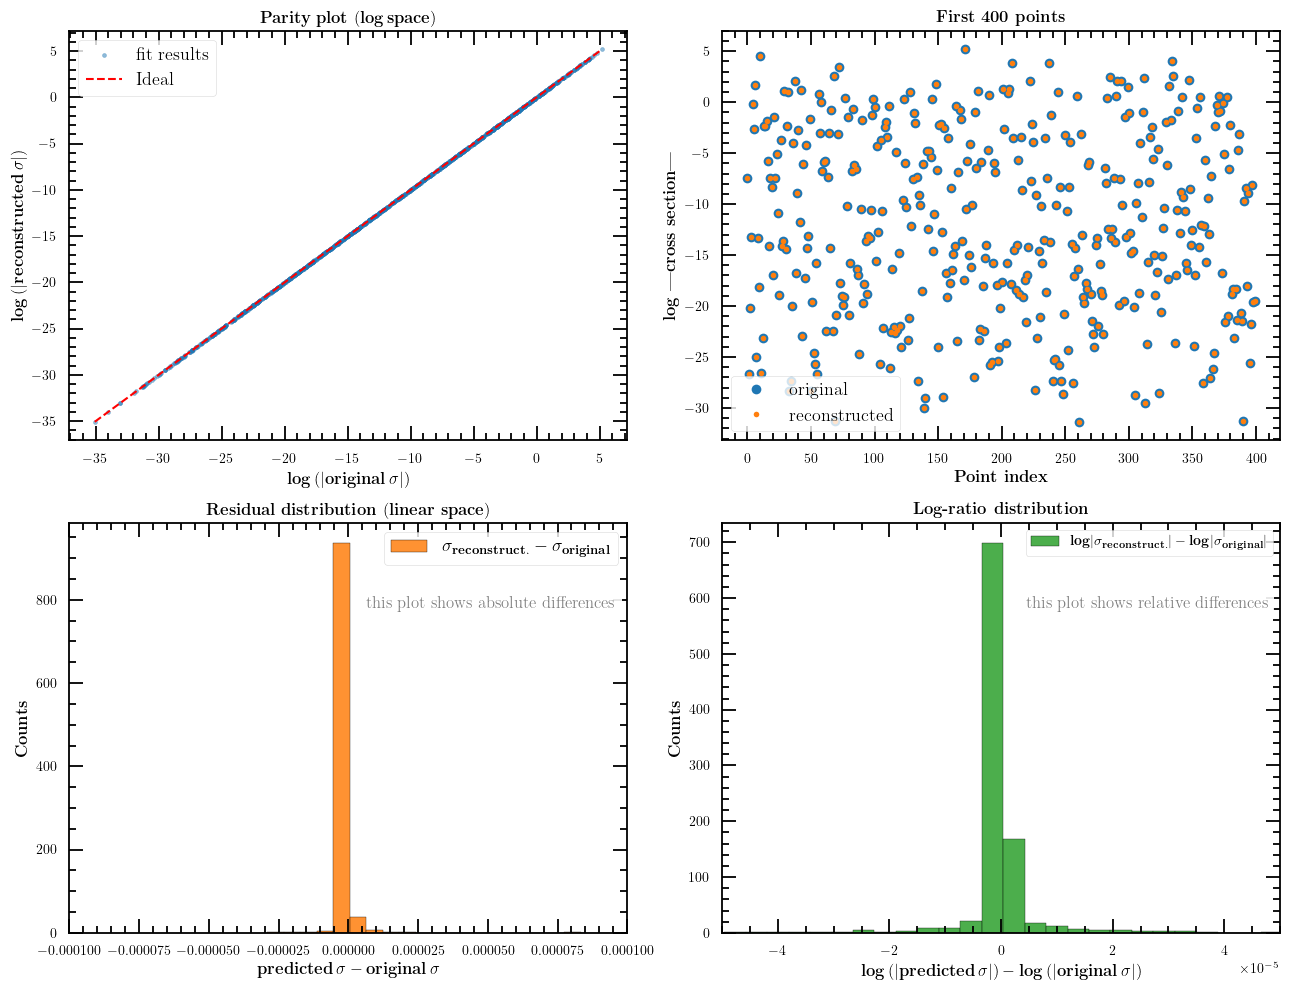

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# -------------------------------------------------------------------------------------------------
# Parity plot in log-space
# -------------------------------------------------------------------------------------------------
ax = axes[0, 0]
ax.scatter(log_true, log_pred, s=8, alpha=0.5, color='tab:blue', label='fit results')
mn = min(log_true.min(), log_pred.min())
mx = max(log_true.max(), log_pred.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Ideal')
ax.set_xlabel(r'$\mathbf{log \left(|original \, \sigma|\right)}$')
ax.set_ylabel(r'$\mathbf{log \left(|reconstructed \, \sigma|\right)}$')
ax.set_title(r'$\mathbf{Parity\, \,plot\, \,(log \,space)}$')
ax.legend()

# -------------------------------------------------------------------------------------------------
# Residual histogram (linear space)
# -------------------------------------------------------------------------------------------------
ax = axes[1, 0]
ax.hist(residual, bins=70, color='tab:orange', alpha=0.85, edgecolor='black', linewidth=0.3, label=r'$\mathbf{\sigma_{reconstruct.} - \sigma_{original}}$')
ax.set_xlim(-1e-4, 1e-4)
ax.set_xlabel(r'$\mathbf{predicted \, \sigma - original \, \sigma}$')
ax.set_ylabel(r'$\mathbf{Counts}$')
ax.legend()
ax.set_title(r'$\mathbf{Residual\, \,distribution\, \,(linear\, \,space)}$')
# Add text annotation to emphasize relative differences
ax.text(0.98, 0.82, "this plot shows absolute differences",
        transform=ax.transAxes, fontsize=12,
        color='gray', ha='right', va='top', bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))

# -------------------------------------------------------------------------------------------------
# Log-ratio histogram
# -------------------------------------------------------------------------------------------------
ax = axes[1, 1]
ax.hist(log_ratio, bins=70, color='tab:green', alpha=0.85, edgecolor='black', linewidth=0.3, label=r'$\mathbf{log|\sigma_{reconstruct.}| - log|\sigma_{original}|}$')
ax.set_xlim(-5e-5, 5e-5)
ax.set_xlabel(r'$\mathbf{log\left(|predicted\,\sigma|\right) - log\left(|original\,\sigma|\right)}$')
ax.set_ylabel(r'$\mathbf{Counts}$')
ax.legend(fontsize=10)
ax.set_title(r'\textbf{Log-ratio distribution}')
# Add text annotation to emphasize relative differences
ax.text(0.98, 0.82, "this plot shows relative differences",
        transform=ax.transAxes, fontsize=12,
        color='gray', ha='right', va='top', bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))

# -------------------------------------------------------------------------------------------------
# Point-by-point trend (first N points to keep readable)
# -------------------------------------------------------------------------------------------------
ax = axes[0, 1]
N = min(400, len(df))
ax.plot(np.arange(N), log_true[:N], label='original', lw=1.5, color='tab:blue', marker='o', markersize=7, linestyle='')
ax.plot(np.arange(N), log_pred[:N], label='reconstructed', lw=1.2, color='tab:orange', marker='o', markersize=4, linestyle='')
ax.set_xlabel(r'\textbf{Point index}')
ax.set_ylabel(r'\textbf{log |cross section|}')
ax.set_title(fr'\textbf{{First {N} points}}')
ax.legend()

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/cross_section_comparison.pdf", bbox_inches="tight", pad_inches=0.8)
plt.show()

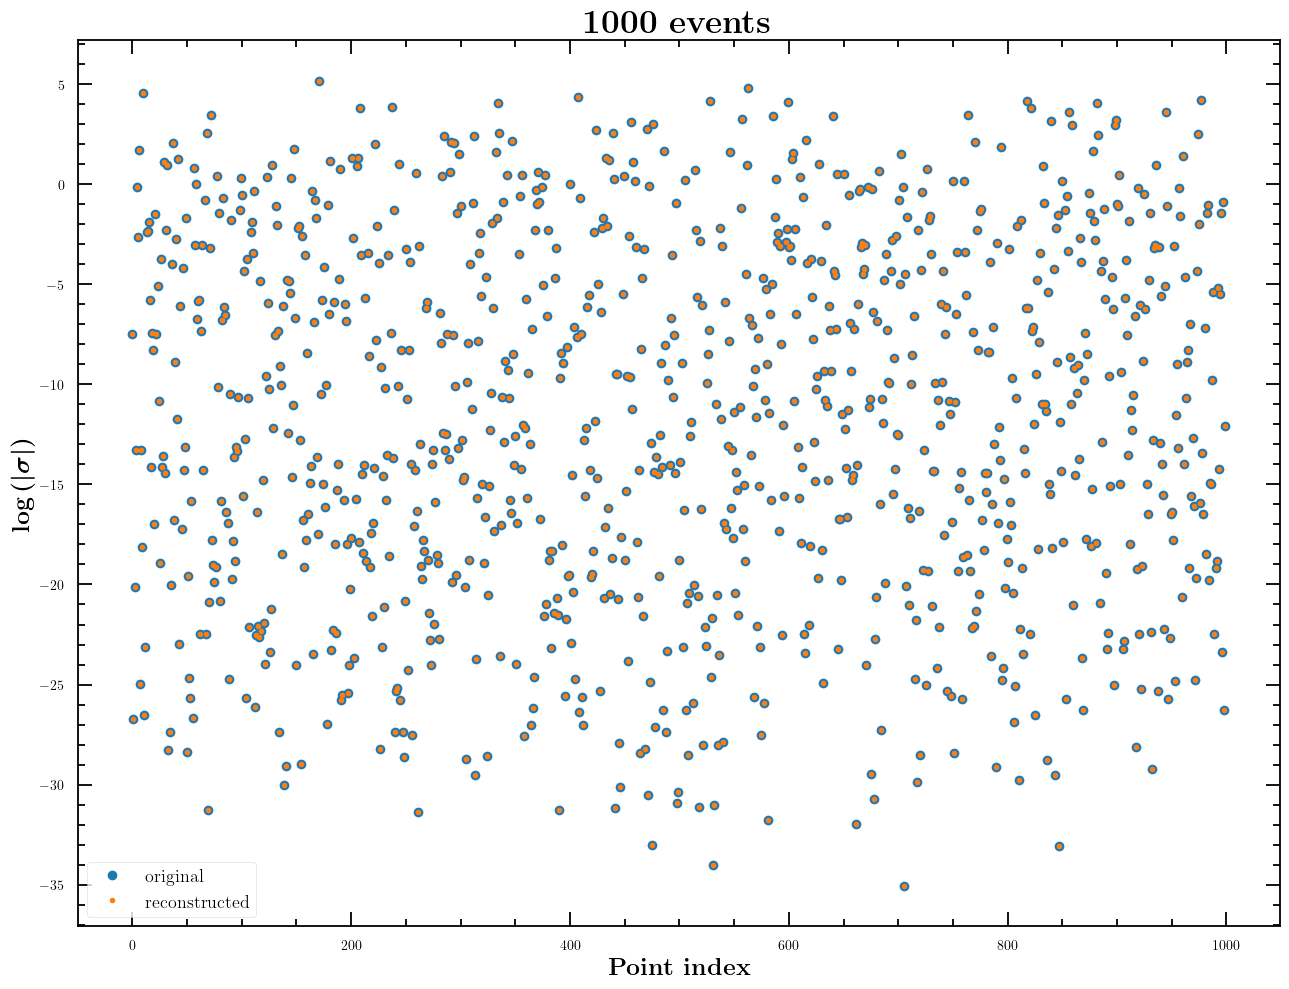

In [8]:
# Point-by-point trend (first N points to keep readable)

fig, ax = plt.subplots(figsize=(13, 10))
N = min(1000, len(df))
ax.plot(np.arange(N), log_true, label='original', lw=1.5, color='tab:blue', marker='o', markersize=7, linestyle='')
ax.plot(np.arange(N), log_pred, label='reconstructed', lw=1.2, color='tab:orange', marker='o', markersize=4, linestyle='')
ax.set_xlabel(r'\textbf{Point index}', fontsize=18)
ax.set_ylabel(r'$\bm{\log \left(|\sigma|\right)}$', fontsize=18)
ax.set_title(fr'\textbf{{{N} events}}', fontsize=24)
ax.legend()

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/cross_section_comparison_point_by_point.pdf", bbox_inches="tight", pad_inches=0.3)
plt.show()

In [9]:
# Recovery table (matches runfit.py terminal output)
param_df_sorted = param_df.sort_values('parameter').reset_index(drop=True)
train_params = param_df_sorted[param_df_sorted['fit_role'] == 'trainable_direct'].copy()

if len(train_params) == 0:
    print('No trainable_direct parameters found.')
else:
    abs_rel = np.abs(train_params['rel_diff'].astype(float))
    train_params['Recovery'] = np.select(
        [abs_rel < 0.05, abs_rel < 0.20],
        ['Excellent', 'Partial'],
        default='Poor'
    )

    recovery_table = train_params[
        ['parameter', 'truth', 'initial', 'final', 'diff', 'rel_diff', 'Recovery']
    ].rename(columns={
        'parameter': 'Parameter',
        'truth': 'Truth',
        'initial': 'Initial',
        'final': 'Final',
        'diff': 'Abs.Diff',
        'rel_diff': 'Rel.Diff%'
    }).copy()

    # Format exactly like terminal columns
    recovery_table['Truth'] = recovery_table['Truth'].map(lambda v: f"{v:0.6f}")
    recovery_table['Initial'] = recovery_table['Initial'].map(lambda v: f"{v:0.6f}")
    recovery_table['Final'] = recovery_table['Final'].map(lambda v: f"{v:0.6f}")
    recovery_table['Abs.Diff'] = recovery_table['Abs.Diff'].map(lambda v: f"{v:+0.6f}")
    recovery_table['Rel.Diff%'] = recovery_table['Rel.Diff%'].map(lambda v: f"{v*100:+0.2f}%")

    print('Recovery per trainable parameter:')
    display(recovery_table)

Recovery per trainable parameter:


,Parameter,Truth,Initial,Final,Abs.Diff,Rel.Diff%,Recovery
0,evolution.g2,0.128400,0.111472,0.128378,-0.000022,-0.02%,Excellent
5,ffs.d[0],0.200000,0.542247,0.187660,-0.012340,-6.17%,Partial
6,ffs.d[1],0.300000,0.855872,0.010000,-0.290000,-96.67%,Poor
13,ffs.u[0],0.400000,1.352502,0.404188,+0.004188,+1.05%,Excellent
14,ffs.u[1],0.300000,1.317212,0.320279,+0.020279,+6.76%,Partial
21,pdfs.d[0],0.250000,0.250000,0.261571,+0.011571,+4.63%,Excellent
22,pdfs.d[1],0.150000,0.150000,0.189395,+0.039395,+26.26%,Poor
29,pdfs.u[0],0.500000,0.581430,0.499131,-0.000869,-0.17%,Excellent
30,pdfs.u[1],0.300000,0.278923,0.298492,-0.001509,-0.50%,Excellent


## III. Parameters


In [10]:
# Sort for readability
param_df_sorted = param_df.sort_values('parameter').reset_index(drop=True)

# # Check
# print(param_df_sorted.head(5))


### recovery table

In [11]:
# Recovery table with runfit.py terminal columns (no HTML Styler escape issues)
train_params = param_df_sorted[param_df_sorted['fit_role'] == 'trainable_direct'].copy()

if len(train_params) == 0:
    print('No trainable_direct parameters found.')
else:
    abs_rel = np.abs(train_params['rel_diff'].astype(float))
    train_params['Recovery'] = np.select(
        [abs_rel < 0.05, abs_rel < 0.20],
        ['Excellent', 'Partial'],
        default='Poor'
    )

    table_df = train_params[
        ['parameter', 'truth', 'initial', 'final', 'diff', 'rel_diff', 'Recovery']
    ].rename(columns={
        'parameter': 'Parameter',
        'truth': 'Truth',
        'initial': 'Initial',
        'final': 'Final',
        'diff': 'Abs.Diff',
        'rel_diff': 'Rel.Diff%'
    }).copy()

    # Match runfit.py number formatting
    table_df['Truth'] = table_df['Truth'].map(lambda v: f"{v:0.6f}")
    table_df['Initial'] = table_df['Initial'].map(lambda v: f"{v:0.6f}")
    table_df['Final'] = table_df['Final'].map(lambda v: f"{v:0.6f}")
    table_df['Abs.Diff'] = table_df['Abs.Diff'].map(lambda v: f"{v:+0.6f}")
    table_df['Rel.Diff%'] = table_df['Rel.Diff%'].map(lambda v: f"{v*100:+0.2f}%")

    print('Recovery per trainable parameter:')
    display(table_df)

Recovery per trainable parameter:


,Parameter,Truth,Initial,Final,Abs.Diff,Rel.Diff%,Recovery
0,evolution.g2,0.128400,0.111472,0.128378,-0.000022,-0.02%,Excellent
5,ffs.d[0],0.200000,0.542247,0.187660,-0.012340,-6.17%,Partial
6,ffs.d[1],0.300000,0.855872,0.010000,-0.290000,-96.67%,Poor
13,ffs.u[0],0.400000,1.352502,0.404188,+0.004188,+1.05%,Excellent
14,ffs.u[1],0.300000,1.317212,0.320279,+0.020279,+6.76%,Partial
21,pdfs.d[0],0.250000,0.250000,0.261571,+0.011571,+4.63%,Excellent
22,pdfs.d[1],0.150000,0.150000,0.189395,+0.039395,+26.26%,Poor
29,pdfs.u[0],0.500000,0.581430,0.499131,-0.000869,-0.17%,Excellent
30,pdfs.u[1],0.300000,0.278923,0.298492,-0.001509,-0.50%,Excellent


### recovery plots

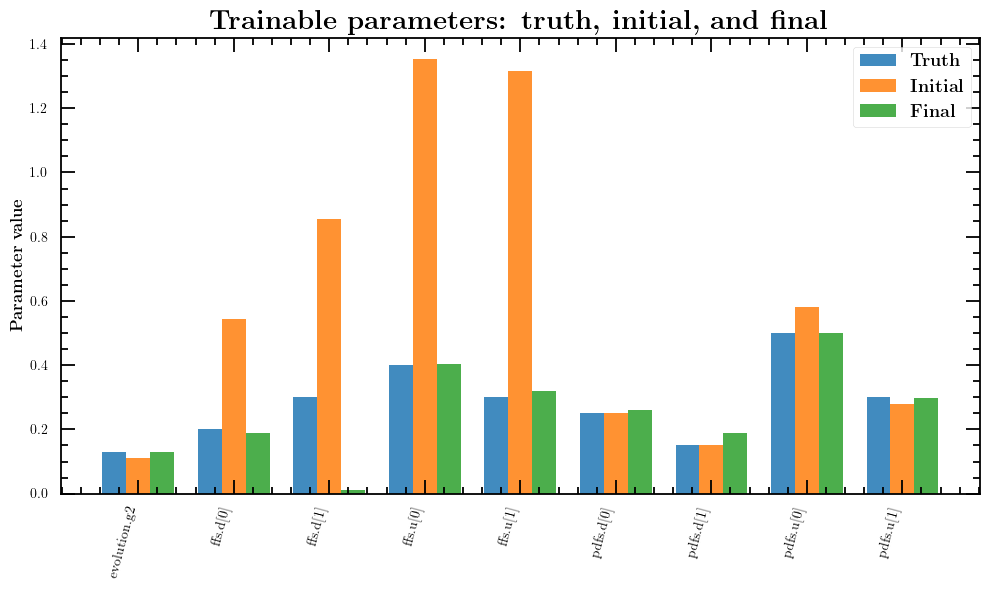

Max absolute shift among fixed parameters: 0.000e+00


In [12]:
# Bar chart: truth vs final for trainable direct parameters
trainable = param_df_sorted[param_df_sorted['fit_role'] == 'trainable_direct'].copy()

if len(trainable) == 0:
    print('No trainable_direct parameters found.')
else:
    x = np.arange(len(trainable))
    w = 0.42

    fig, ax = plt.subplots(figsize=(max(10, 0.65 * len(trainable)), 6))
    w = 0.25  # Make bars a bit narrower for clarity

    # Three bars per parameter (centered at x)
    ax.bar(x - w, trainable['truth'], width=w, label=r'\textbf{Truth}', alpha=0.85)
    ax.bar(x,      trainable['initial'], width=w, label=r'\textbf{Initial}', alpha=0.85)
    ax.bar(x + w, trainable['final'], width=w, label=r'\textbf{Final}', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(trainable['parameter'], rotation=75, ha='right')
    ax.set_ylabel(r'\textbf{Parameter value}')
    ax.set_title(r'\textbf{Trainable parameters: truth, initial, and final}', fontsize=20)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/trainable_parameters_truth_initial_final.pdf", bbox_inches="tight", pad_inches=0.5)
    plt.show()

# Fixed parameters should not move. Print out the check.
fixed = param_df_sorted[param_df_sorted['is_fixed'] == True]
if len(fixed) > 0:
    max_fixed_shift = np.abs(fixed['diff'].fillna(0.0)).max()
    print(f'Max absolute shift among fixed parameters: {max_fixed_shift:.3e}')

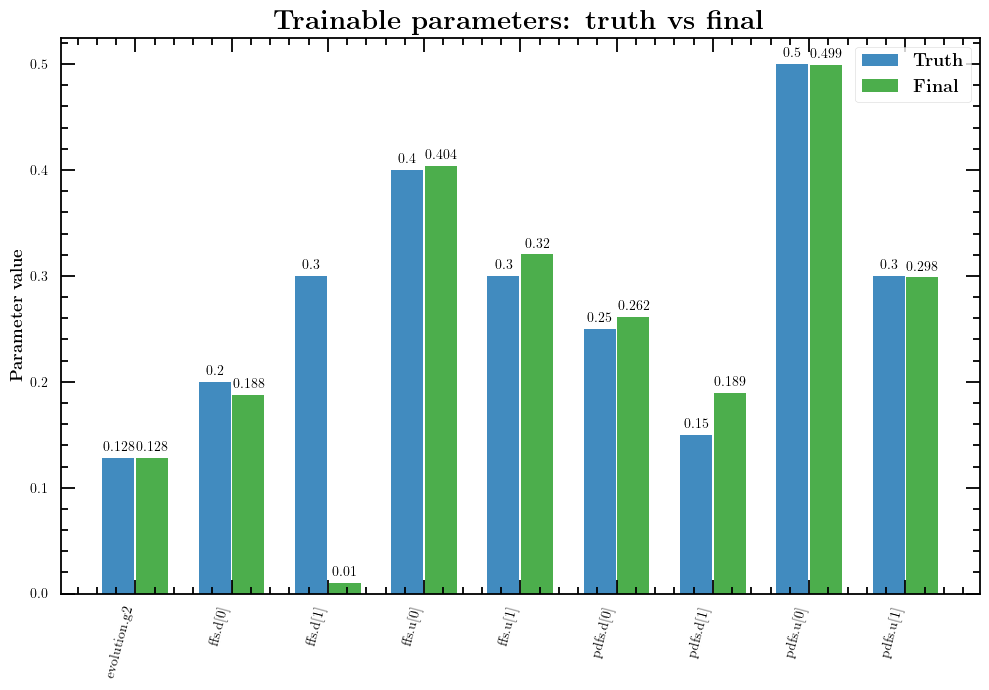

In [13]:
# Bar chart: truth vs final for trainable direct parameters
trainable = param_df_sorted[param_df_sorted['fit_role'] == 'trainable_direct'].copy()

if len(trainable) == 0:
    print('No trainable_direct parameters found.')
else:
    x = np.arange(len(trainable))
    group_width = 0.70  # Total width allotted to the pair of bars per parameter
    bar_width = group_width / 2  # space for each bar

    fig, ax = plt.subplots(figsize=(max(10, 0.95 * len(trainable)), 7))

    truth_bars = ax.bar(
        x - bar_width/2, 
        trainable['truth'], 
        width=bar_width * 0.95, 
        label=r'\textbf{Truth}', 
        alpha=0.85
    )
    final_bars = ax.bar(
        x + bar_width/2, 
        trainable['final'], 
        width=bar_width * 0.95, 
        label=r'\textbf{Final}', 
        alpha=0.85, 
        color='tab:green'
    )

    ax.set_xticks(x)
    ax.set_xticklabels(trainable['parameter'], rotation=75, ha='right')
    ax.set_ylabel(r'\textbf{Parameter value}')
    ax.set_title(r'\textbf{Trainable parameters: truth vs final}', fontsize=20)
    ax.legend()

    # Annotate top of bars with value
    # Format: 3 significant digits, align text to middle, just above bar
    for idx, bar in enumerate(truth_bars):
        val = trainable['truth'].iloc[idx]
        ax.annotate(f"{val:.3g}", 
                    (bar.get_x() + bar.get_width()/2, bar.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=10, 
                    xytext=(0,3),
                    textcoords='offset points'
        )
    for idx, bar in enumerate(final_bars):
        val = trainable['final'].iloc[idx]
        ax.annotate(f"{val:.3g}", 
                    (bar.get_x() + bar.get_width()/2, bar.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=10, 
                    xytext=(0,3),
                    textcoords='offset points'
        )

    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/trainable_parameters_truth_vs_final.pdf", bbox_inches="tight", pad_inches=0.5)
    plt.show()


## IV Goodness-of-Fit Diagnostics

Common checks included here:
- Log-space MSE / RMSE
- MAE and relative MAE
- Correlation in log-space
- Reduced-chi2-like indicator (using original values as scale)
- Pull distribution and residual trends vs kinematics

In [14]:
with open(FIT_LOSS_FILE, 'r') as f:
    fit_loss = yaml.safe_load(f)
    
# Goodness-of-fit indicators from fitresults/loss.yaml
# We read sampled training losses from fit_loss['loss'].
loss_entries = fit_loss.get('loss', [])
loss_info = fit_loss.get('loss_info', {})

if len(loss_entries) == 0:
    print('No loss entries found in loss.yaml.')
else:
    loss_track = pd.DataFrame(loss_entries).sort_values('epoch').reset_index(drop=True)

    initial_loss = float(loss_track['loss'].iloc[0])
    final_loss = float(loss_track['loss'].iloc[-1])
    best_loss = float(loss_track['loss'].min())
    best_epoch = int(loss_track.loc[loss_track['loss'].idxmin(), 'epoch'])

    # Final log-RMSE derived from final log-MSE
    final_log_rmse = np.sqrt(final_loss)

    # Percent reduction from first sampled point to final sampled point
    if initial_loss > 0:
        reduction_percent = (initial_loss - final_loss) / initial_loss * 100.0
    else:
        reduction_percent = np.nan

    # In runfit.py losses are typically recorded every 10 epochs
    if len(loss_track) > 1:
        epoch_step = int(loss_track['epoch'].diff().dropna().median())
    else:
        epoch_step = np.nan

    print(f'{tcolors.BOLDBLUE}------------------------------------------------{tcolors.ENDC}')
    print(f'{tcolors.BOLDBLUE}--- Goodness-of-fit summary (from loss.yaml) ---{tcolors.ENDC}')
    print(f'{tcolors.BOLDBLUE}------------------------------------------------{tcolors.ENDC}')
    print(f"{tcolors.BOLDGREEN}Events               : {fit_loss.get('n_events', len(cross_section_df))}{tcolors.ENDC}")
    print(f"Parameters listed    : {len(param_df_sorted)}")
    print(f"trainable parameters : {fit_loss.get('trainable_parameters', [])}")
    print(f"Epochs               : {fit_loss.get('n_epochs', 'N/A')}")
    print(f"Seed                 : {fit_loss.get('seed', 'N/A')}")
    print(f"Loss sample step     : every ~{epoch_step} epochs")
    print(f"Initial log-MSE      : {initial_loss:.6e}")
    print(f"Final log-MSE        : {final_loss:.6e}")
    print(f"Final log-RMSE       : {final_log_rmse:.6e}")
    print(f"{tcolors.BOLDGREEN}Best sampled log-MSE : {best_loss:.6e} (epoch {best_epoch}){tcolors.ENDC}")
    print(f"Loss reduction       : {reduction_percent:.6f}%")

------------------------------------------------
--- Goodness-of-fit summary (from loss.yaml) ---
------------------------------------------------
Events               : 1000
Parameters listed    : 33
trainable parameters : 9
Epochs               : 1500
Seed                 : 7
Loss sample step     : every ~10 epochs
Initial log-MSE      : 1.838311e-04
Final log-MSE        : 1.766574e-10
Final log-RMSE       : 1.329125e-05
Best sampled log-MSE : 1.756815e-10 (epoch 1370)
Loss reduction       : 99.999904%


### Note on the goodness-of-fit indicators

The summary above is read from `fitresults/loss.yaml` and reports training-loss behavior:

- **Initial log-MSE**: first sampled value of the training loss (`log_mse`) at the beginning of minimization.
- **Final log-MSE**: last sampled value written to `loss.yaml`.
- **Final log-RMSE**: square root of the final log-MSE. It has the same scale as log residuals.
- **Best sampled log-MSE (epoch N)**: minimum sampled loss and the epoch where it occurred.
- **Loss reduction (%)**: relative decrease from initial to final sampled loss.
- **Loss sample step**: approximate epoch interval between saved samples (typically every 10 epochs).

Interpretation: lower final/best log-MSE and larger reduction generally indicate better convergence of the fit objective.

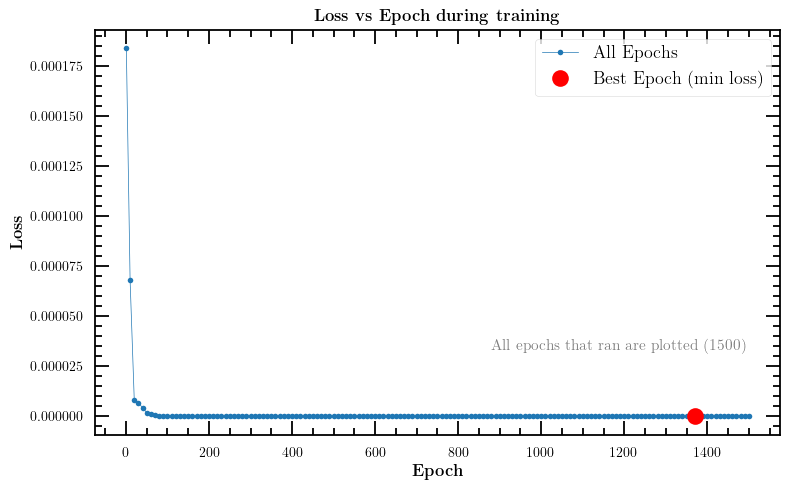

In [15]:
# Plot loss function value vs number of epochs/iterations.
fig, ax = plt.subplots(figsize=(8, 5))

# If available, use columns "epoch" and "loss" or "log_mse", else adapt as necessary
if 'epoch' in loss_track.columns and 'loss' in loss_track.columns:
    x = loss_track['epoch']
    y = loss_track['loss']
    ylabel = "Loss"
elif 'epoch' in loss_track.columns and 'log_mse' in loss_track.columns:
    x = loss_track['epoch']
    y = loss_track['log_mse']
    ylabel = "Log-MSE"
else:
    # fallback for column names
    x = np.arange(len(loss_track))
    y = loss_track.iloc[:, 1]
    ylabel = loss_track.columns[1]

# Plot all epochs/points with blue
ax.plot(x, y, marker='o', color='tab:blue', markersize=4, linestyle='-', linewidth=0.5, label="All Epochs")

# Mark the best epoch (minimum loss)
best_idx = y.idxmin() if hasattr(y, 'idxmin') else np.argmin(y)
best_x = x[best_idx]
best_y = y[best_idx]
ax.plot(best_x, best_y, marker='o', color='red', markersize=12, linestyle='None', label="Best Epoch (min loss)")

# Add legend to distinguish best epoch
ax.legend()

# Add note about all epochs being plotted
ax.text(0.95, 0.20, f"All epochs that ran are plotted ({fit_loss.get('n_epochs', 'N/A')})", ha='right', va='bottom',
        transform=ax.transAxes, fontsize=11, color='gray')

ax.set_xlabel(r"\textbf{Epoch}")
ax.set_ylabel(rf"\textbf{{{ylabel}}}")
ax.set_title(rf"\textbf{{{ylabel} vs Epoch during training}}")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/loss_vs_epoch_all.pdf", bbox_inches="tight", pad_inches=0.5)
plt.show()

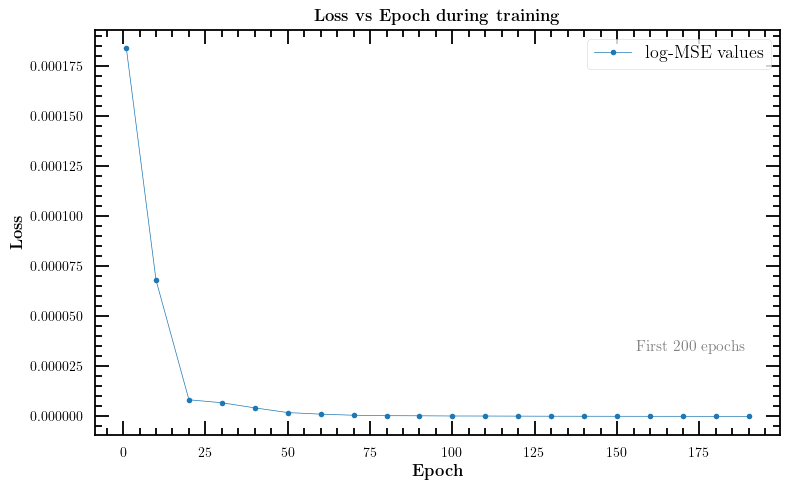

In [16]:
# Plot loss function value vs number of epochs/iterations.
fig, ax = plt.subplots(figsize=(8, 5))

number_of_registered_epochs_to_plot = 20

# If available, use columns "epoch" and "loss" or "log_mse", else adapt as necessary
if 'epoch' in loss_track.columns and 'loss' in loss_track.columns:
    x = loss_track['epoch'][:number_of_registered_epochs_to_plot]
    y = loss_track['loss'][:number_of_registered_epochs_to_plot]
    ylabel = "Loss"

ax.plot(x, y, marker='o', color='tab:blue', markersize=4, linestyle='-', linewidth=0.5, label=r"log-MSE values")
ax.set_xlabel(r"\textbf{Epoch}")
ax.set_ylabel(rf"\textbf{{{ylabel}}}")
ax.set_title(rf"\textbf{{{ylabel} vs Epoch during training}}")

# Add note about all epochs being plotted
ax.text(0.95, 0.20, f"First {number_of_registered_epochs_to_plot * 10} epochs", ha='right', va='bottom',
        transform=ax.transAxes, fontsize=11, color='gray')

ax.legend()

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/loss_vs_epoch_first{number_of_registered_epochs_to_plot * 10}.pdf", bbox_inches="tight", pad_inches=0.5)
plt.show()